In [1]:
import pandas as pd

In [3]:
import pandas as pd
import plotly.graph_objects as go

# данные
df = pd.DataFrame({
    'ts_name': [
        'ts_name_2', 'ts_name_3', 'ts_name_11', 'ts_name_8',
        'ts_name_4', 'ts_name_5', 'ts_name_0', 'ts_name_1',
        'ts_name_9', 'ts_name_10', 'ts_name_6', 'ts_name_7'
    ],
    'before_adjustment': [
        29.91, 14.07, 47.92, 32.42,
        14.06, 14.22, 12.44, 9.37,
        40.73, 20.95, 14.36, 11.61
    ],
    'after_adjustment': [
        29.27, 14.53, 47.82, 32.33,
        13.16, 14.22, 12.17, 9.17,
        40.51, 20.93, 14.04, 13.96
    ]
})

# график
fig = go.Figure()

# до корректировки
fig.add_trace(
    go.Scatter(
        x=df['ts_name'],
        y=df['before_adjustment'],
        mode='lines+markers',
        name='До корректировки'
    )
)

# после корректировки
fig.add_trace(
    go.Scatter(
        x=df['ts_name'],
        y=df['after_adjustment'],
        mode='lines+markers',
        name='После корректировки'
    )
)

# оформление
fig.update_layout(
    title='Сравнение WAPE до и после корректировки новогодних праздников',
    xaxis_title='Временной ряд',
    yaxis_title='WAPE (%)',
    template='plotly_white',
    width=800,
    height=400
)



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'mode': 'lines+markers',
              'name': 'До корректировки',
              'type': 'scatter',
              'x': array(['ts_name_2', 'ts_name_3', 'ts_name_11', 'ts_name_8', 'ts_name_4',
                          'ts_name_5', 'ts_name_0', 'ts_name_1', 'ts_name_9', 'ts_name_10',
                          'ts_name_6', 'ts_name_7'], dtype=object),
              'y': {'bdata': ('KVyPwvXoPUCkcD0K1yMsQPYoXI/C9U' ... 'MzMzPzNEC4HoXrUbgsQLgehetROCdA'),
                    'dtype': 'f8'}},
             {'mode': 'lines+markers',
              'name': 'После корректировки',
              'type': 'scatter',
              'x': array(['ts_name_2', 'ts_name_3', 'ts_name_11', 'ts_name_8', 'ts_name_4',
                          'ts_name_5', 'ts_name_0', 'ts_name_1', 'ts_name_9', 'ts_name_10',
                          'ts_name_6', 'ts_name_7'], dtype=object),
              'y': {'bdata': ('hetRuB5FPUCPwvUoXA8tQClcj8L16E' ... 'fhehTuNEAUrkfhehQsQOxRuB6F6ytA'),
                    'dtype': 'f8'}}],
    'layout': {'height': 400,
               'template': '...',
               'title': {'text': 'Сравнение WAPE до и после корректировки новогодних праздников'},
               'width': 800,
               'xaxis': {'title': {'text': 'Временной ряд'}},
               'yaxis': {'title': {'text': 'WAPE (%)'}}}
})

In [5]:
import pandas as pd

data = pd.read_csv('data.csv')

stats_df = (
    data.groupby('ts_name')['y']
    .agg([
        'count',
        'mean',
        'median',
        'std',
        'min',
        'max'
    ])
    .reset_index()
)

stats_df.columns = [
    'ts_name',
    'Количество наблюдений',
    'Среднее',
    'Медиана',
    'Стандартное отклонение',
    'Минимум',
    'Максимум'
]

print(stats_df.round(2))

       ts_name  Количество наблюдений  Среднее  Медиана  \
0    ts_name_0                  52068   523.52    453.0   
1    ts_name_1                  52080  1353.32   1234.0   
2   ts_name_10                  46952    33.30     30.0   
3   ts_name_11                  17854     3.09      2.0   
4    ts_name_2                  52000    86.53     53.0   
5    ts_name_3                  52072   212.85    191.0   
6    ts_name_4                  52068   217.46    217.0   
7    ts_name_5                  52080   796.14    755.5   
8    ts_name_6                  52068  1354.66   1281.0   
9    ts_name_7                  52080  3949.24   4033.0   
10   ts_name_8                  38899    11.68      7.0   
11   ts_name_9                  34925     4.06      3.0   

    Стандартное отклонение  Минимум  Максимум  
0                   425.78       14     16920  
1                   882.37        2     12806  
2                    25.90        1      2040  
3                     2.35        1     

15:25:08 - cmdstanpy - INFO - Chain [1] start processing
15:25:08 - cmdstanpy - INFO - Chain [1] done processing


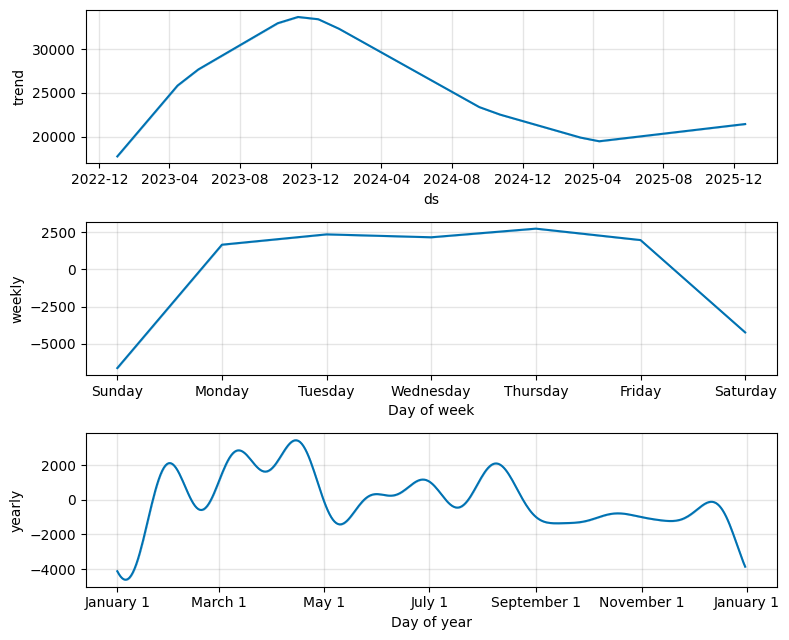

In [16]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('data.csv')
ts = data[data['ts_name'] == 'ts_name_0'].copy()

daily = (
    ts.assign(ds=pd.to_datetime(ts['dttm_30']).dt.date)
      .groupby('ds')['y']
      .sum()
      .reset_index()
)

daily['ds'] = pd.to_datetime(daily['ds'])

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True
)

model.fit(daily)

forecast = model.predict(daily)

# Уменьшаем размер картинки (ширина, высота) в дюймах
fig = model.plot_components(forecast, figsize=(8, 6.5))  # по умолчанию (12, 9) или больше
plt.tight_layout()  # уплотняем отступы
plt.show()

<Figure size 1200x700 with 0 Axes>

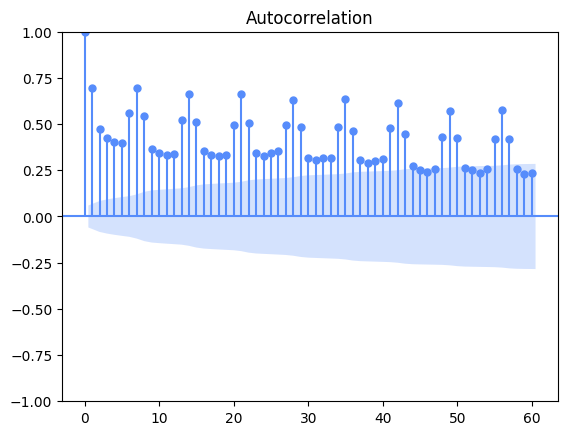

In [20]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

series = daily['y']

plt.figure(figsize=(12,7))
plot_acf(series, lags=60)
plt.show()